--- inicio del taller ---
Creando un rombododecaedro
Malla generada con 24 caras triangulares
magnitud en 1: True
caras al reves: 0
error vs libreria: 3.536060362186783e-13


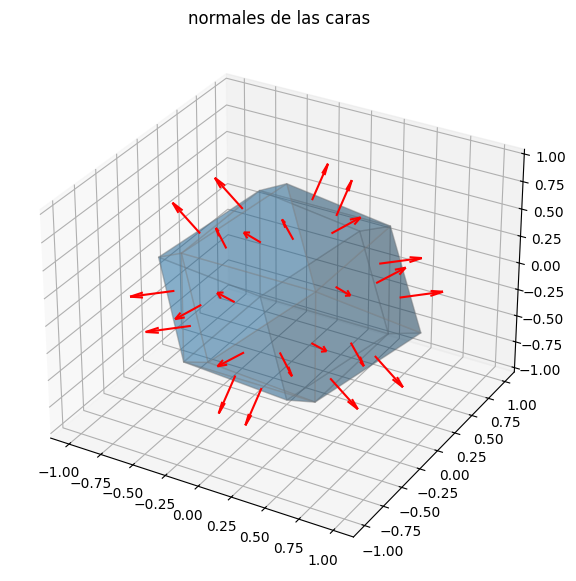

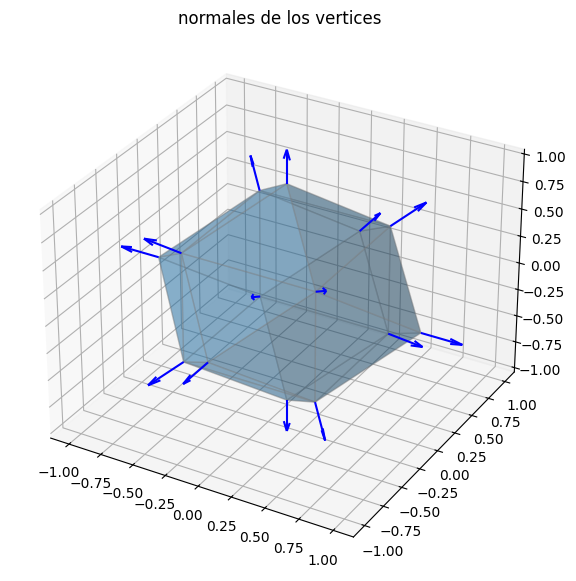

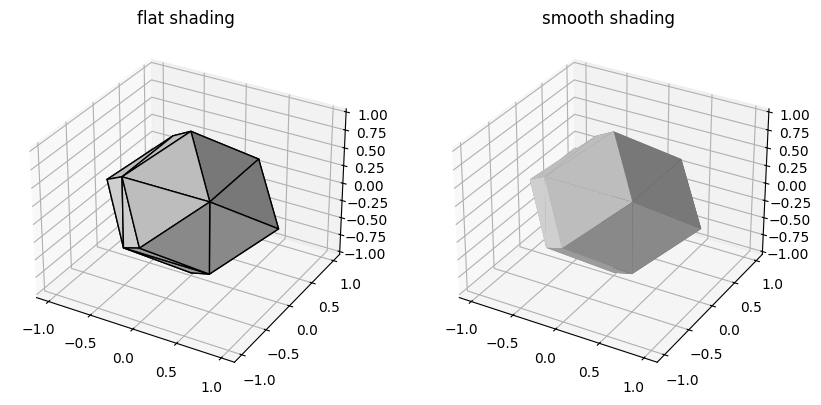

In [5]:
# instalamos la libreria
!pip install trimesh

import numpy as np
import trimesh
import matplotlib.pyplot as plt

def taller_normales_grupo7():
    print("--- inicio del taller ---")
    print("Creando un rombododecaedro")

    # Definir los 14 vértices del rombododecaedro:
    vertices_list = []

    # Vértices axiales
    for axis in range(3):
        for sign in [-1, 1]:
            p = [0, 0, 0]
            p[axis] = sign * 1.0
            vertices_list.append(p)

    # Vértices de las esquinas
    for sx in [-1, 1]:
        for sy in [-1, 1]:
            for sz in [-1, 1]:
                vertices_list.append([sx * 0.5, sy * 0.5, sz * 0.5])

    puntos = np.array(vertices_list)

    # Crear la malla mediante la cápsula convexa de los puntos
    mesh = trimesh.convex.convex_hull(puntos)
    print("Malla generada con", len(mesh.faces), "caras triangulares")

    vertices = mesh.vertices
    faces = mesh.faces

    # sacar puntos del triangulo
    a = vertices[faces[:, 0]]
    b = vertices[faces[:, 1]]
    c = vertices[faces[:, 2]]

    # vectores de los bordes
    v1 = b - a
    v2 = c - a

    # hacer el producto cruz
    normales_caras = np.cross(v1, v2)

    # normalizar para magnitud 1
    normas = np.linalg.norm(normales_caras, axis=1, keepdims=True)
    normales_caras = normales_caras / (normas + 1e-12)

    # revisar que midan uno
    magnitudes = np.linalg.norm(normales_caras, axis=1)
    print("magnitud en 1:", np.allclose(magnitudes, 1.0))

    # centros para las flechas
    centros = vertices[faces].mean(axis=1)

    # ver si hay invertidas
    puntos_prueba = np.sum(centros * normales_caras, axis=1)
    malas = np.where(puntos_prueba < 0)[0]
    print("caras al reves:", len(malas))

    # arreglar normales invertidas
    if len(malas) > 0:
        normales_caras[malas] *= -1

    # calcular para los vertices
    normales_vert = np.zeros(vertices.shape)

    # promediar caras vecinas
    for i, face in enumerate(faces):
        for v in face:
            normales_vert[v] += normales_caras[i]

    # normalizar resultado final
    normas_v = np.linalg.norm(normales_vert, axis=1, keepdims=True)
    normales_vert = normales_vert / (normas_v + 1e-12)

    # chequear contra trimesh
    auto = mesh.vertex_normals
    error = np.max(np.linalg.norm(normales_vert - auto, axis=1))
    print("error vs libreria:", error)

    # dibujo de las caras
    fig1 = plt.figure(figsize=(7, 7))
    ax1 = fig1.add_subplot(111, projection='3d')
    ax1.set_title("normales de las caras")
    ax1.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], triangles=faces, alpha=0.3, edgecolor='gray')
    ax1.quiver(centros[:,0], centros[:,1], centros[:,2],
               normales_caras[:,0], normales_caras[:,1], normales_caras[:,2], length=0.3, color='red')
    plt.show()

    # dibujo de los vertices
    fig2 = plt.figure(figsize=(7, 7))
    ax2 = fig2.add_subplot(111, projection='3d')
    ax2.set_title("normales de los vertices")
    ax2.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], triangles=faces, alpha=0.3, edgecolor='gray')
    ax2.quiver(vertices[:,0], vertices[:,1], vertices[:,2],
               normales_vert[:,0], normales_vert[:,1], normales_vert[:,2], length=0.3, color='blue')
    plt.show()

    # comparacion final shading
    fig3 = plt.figure(figsize=(10, 5))

    # estilo flat
    ax3_a = fig3.add_subplot(121, projection='3d')
    ax3_a.set_title("flat shading")
    ax3_a.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], triangles=faces, alpha=1, color='lightgray', edgecolor='black')

    # estilo smooth
    ax3_b = fig3.add_subplot(122, projection='3d')
    ax3_b.set_title("smooth shading")
    ax3_b.plot_trisurf(vertices[:,0], vertices[:,1], vertices[:,2], triangles=faces, alpha=1, color='lightgray', linewidth=0)

    plt.show()

# correr todo
taller_normales_grupo7()